# Stage C — независимый ноутбук: дообучение на целевой задаче (STS)

Это самостоятельный ноутбук, не зависит от Stage A/B. Цель — выяснить, **какой лосс лучше всего подходит** для дообучения сильных энкодеров на ru-STS, при условии что мы уже выбрали лучшие модели.

## Что делаем

* **Три энкодера**: `deepvk/USER-bge-m3` (CLS), `intfloat/multilingual-e5-large-instruct` (mean + Instruct-prompt), `Qwen/Qwen3-Embedding-0.6B` (last-token + left-padding + bf16).
* **Четыре лосса**: `cosent` (Su 2022, ранжирующий), `mse` (с per-epoch стандартизацией предсказаний), `angle_acos` (твоя простая arccos-версия), `angle_cmplx` (AnglE-style через комплексные числа).
* **DoRA** включён (одна строчка `use_dora=True` в LoraConfig).
* **Matryoshka** в лоссе: каждый лосс считается на нескольких префиксах эмбеддинга и усредняется. После обучения — отдельный многоразрешающий eval.
* **Train data**: `STSBenchmark-ru train` + (если есть) `STS22-ru train`. Поскольку у `mteb/sts22-crosslingual-sts` официально только test, попытка загрузить train сделана защищённо — если не получается, остаётся только STSB-train. **STSB-dev — единственный val** (в STS22 dev отсутствует). Test — оба.
* **Чекпойнты**: после каждой пары (модель × лосс) сохраняется лучший по val LoRA-адаптер. В конце таблица показывает, какой именно из 12 чекпойнтов брать.

## Архитектурные особенности по моделям

| Модель | Pooling | Padding | dtype | Префикс | LoRA targets |
|---|---|---|---|---|---|
| USER-bge-m3 | CLS | right | fp32/fp16 | — | `query, key, value, output.dense` (XLM-R) |
| mE5-large-instruct | mean | right | fp32/fp16 | `Instruct: ...\nQuery: ` к обоим текстам | `query, key, value, output.dense` (XLM-R) |
| Qwen3-Embedding-0.6B | last-token | **left** | **bf16** | `Instruct: ...\nQuery: ` | `q_proj, k_proj, v_proj, o_proj` (LLaMA-like) |

Целевые модули LoRA подбираются **автоматически** по структуре модели (см. `_detect_lora_targets`).

In [ ]:
#!pip install -q -U "transformers>=4.45" "datasets>=2.18" "peft>=0.11" "accelerate" "scipy" "tqdm" "matplotlib"

In [ ]:
#!pip -q install -U "torch>=2.1" "transformers==4.51.0" "datasets>=2.18" \
 # "huggingface_hub>=0.23" "scipy>=1.11" "tqdm>=4.66" "accelerate>=0.30" \
 # "sentence-transformers>=5.1.1"
#!pip install --upgrade --force-reinstall torchvision

In [ ]:
#!pip uninstall -y torch torchvision torchaudio torchao
#!pip install torch==2.10.0 torchvision==0.25.0 torchaudio==2.10.0 --index-url https://download.pytorch.org/whl/cu121
#!pip install -U "transformers>=4.40" "datasets>=2.18" "peft==0.12.0" "accelerate" "scipy" "tqdm"

In [ ]:
import os, math, random, json, gc as _gc
from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional, Callable

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModel, get_cosine_schedule_with_warmup
from peft import LoraConfig, get_peft_model, TaskType, get_peft_model_state_dict, set_peft_model_state_dict
from scipy.stats import pearsonr, spearmanr
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

# ----- глобальная конфигурация -----
USE_DORA          = True
MATRYOSHKA_DIMS   = [1024, 768, 512, 384, 256, 128, 64]   # отрежем по реальной размерности
CHECKPOINT_DIR    = "./checkpoints_stageC"
HISTORY_DIR       = "./histories_stageC"
os.makedirs(CHECKPOINT_DIR, exist_ok=True); os.makedirs(HISTORY_DIR, exist_ok=True)

print(f"USE_DORA={USE_DORA}  MATRYOSHKA_DIMS={MATRYOSHKA_DIMS}")


Using device: cuda
GPU: NVIDIA A100-SXM4-80GB
USE_DORA=True  MATRYOSHKA_DIMS=[1024, 768, 512, 384, 256, 128, 64]


In [ ]:
# ----- Метрика и датасеты -----
def sts_quality(y_true, y_pred):
    p = pearsonr(y_true, y_pred)[0]
    s = spearmanr(y_true, y_pred)[0]
    return float((p + s) / 2.0)

# --- STSB ---
stsb  = load_dataset("PhilipMay/stsb_multi_mt", "ru")
def _prep(ds, s1c="sentence1", s2c="sentence2", yc="similarity_score"):
    s1 = [x[s1c] for x in ds]; s2 = [x[s2c] for x in ds]
    y  = np.array([float(x[yc]) for x in ds], dtype=np.float32)
    return s1, s2, y

stsb_train_s1, stsb_train_s2, stsb_train_y = _prep(stsb["train"])
val_s1,        val_s2,        val_y        = _prep(stsb["dev"])
test_s1,       test_s2,       test_y       = _prep(stsb["test"])
print(f"STSB train: {len(stsb_train_s1)}  dev: {len(val_s1)}  test: {len(test_s1)}")

# --- STS22 ---
sts22 = load_dataset("mteb/sts22-crosslingual-sts", "ru")
print(f"STS22 splits: {list(sts22.keys())}")
sts22_train_s1, sts22_train_s2, sts22_train_y = [], [], np.array([], dtype=np.float32)
if "train" in sts22:
    try:
        sts22_train_s1, sts22_train_s2, sts22_train_y = _prep(sts22["train"], "sentence1", "sentence2", "score")
        print(f"  STS22 train: {len(sts22_train_s1)} pairs (will be merged with STSB train)")
    except Exception as e:
        print(f"  STS22 train: failed to parse ({e}), skipping")
sts22_test_s1,  sts22_test_s2,  sts22_test_y  = _prep(sts22["test"], "sentence1", "sentence2", "score")
print(f"  STS22 test:  {len(sts22_test_s1)} pairs")

# --- объединённый train ---
train_s1 = list(stsb_train_s1) + list(sts22_train_s1)
train_s2 = list(stsb_train_s2) + list(sts22_train_s2)
train_y  = np.concatenate([stsb_train_y, sts22_train_y]) if len(sts22_train_y) else stsb_train_y
print(f"\nTotal train pairs: {len(train_s1)} "
      f"(STSB={len(stsb_train_s1)} + STS22={len(sts22_train_s1)})")
print(f"y range: [{train_y.min():.2f}, {train_y.max():.2f}], mean={train_y.mean():.3f}")

# Глобальные статистики train_y нужны для MSE (нормализация target)
Y_MEAN = float(train_y.mean()); Y_STD = float(train_y.std() + 1e-8)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


STSB train: 5749  dev: 1500  test: 1379
STS22 splits: ['test']
  STS22 test:  265 pairs

Total train pairs: 5749 (STSB=5749 + STS22=0)
y range: [0.00, 5.00], mean=2.701


In [ ]:
# ----- Универсальная модель: XLM-R, mE5-instruct, Qwen3-Embedding -----
def _detect_lora_targets(model) -> List[str]:
    # Берём имена линейных модулей и определяем тип архитектуры по подстрокам.
    names = {n for n, _ in model.named_modules()}
    if any(".q_proj" in n for n in names):       # LLaMA-like (Qwen3)
        targets = ["q_proj", "k_proj", "v_proj", "o_proj"]
    else:                                          # XLM-R-like (BGE-M3, mE5)
        targets = ["query", "key", "value", "output.dense"]
    return targets

def last_token_pool(h, attention_mask):
    # Совместимо как с правым, так и с левым padding (см. карточку Qwen3-Embedding).
    left_padding = (attention_mask[:, -1].sum() == attention_mask.shape[0])
    if left_padding:
        return h[:, -1]
    seq_lens = attention_mask.sum(dim=1) - 1
    bs = h.size(0)
    return h[torch.arange(bs, device=h.device), seq_lens]

E5_INSTRUCT_TASK = "Given a text, retrieve relevant passages"
QWEN_INSTRUCT_TASK = "Retrieve semantically similar text"

@dataclass
class ModelSpec:
    name: str                # display name
    model_id: str
    pooling: str             # "cls" | "mean" | "last"
    prompt: str              # "none" | "e5_instruct"
    is_qwen: bool = False
    dtype: torch.dtype = torch.float32
    max_length: int = 192
    lora_r: int = 16
    lora_alpha: int = 32
    lora_dropout: float = 0.1


class STSEncoder(nn.Module):
    def __init__(self, spec: ModelSpec, mode: str = "lora", use_dora: bool = True):
        super().__init__()
        self.spec = spec
        self.tokenizer = AutoTokenizer.from_pretrained(
            spec.model_id, use_fast=True,
            padding_side="left" if spec.is_qwen else "right",
            trust_remote_code=True,
        )
        kw = {"trust_remote_code": True}
        if spec.dtype != torch.float32:
            kw["torch_dtype"] = spec.dtype
        base = AutoModel.from_pretrained(spec.model_id, **kw)

        if mode == "lora":
            targets = _detect_lora_targets(base)
            cfg_kwargs = dict(r=spec.lora_r, lora_alpha=spec.lora_alpha,
                              lora_dropout=spec.lora_dropout,
                              bias="none", target_modules=targets,
                              task_type=TaskType.FEATURE_EXTRACTION)
            if use_dora:
                # PEFT >= 0.9; на некоторых архитектурах может не поддерживаться
                try:
                    cfg = LoraConfig(**cfg_kwargs, use_dora=True)
                except TypeError:
                    cfg = LoraConfig(**cfg_kwargs)
                    print(f"  [warn] DoRA flag not supported, falling back to plain LoRA")
            else:
                cfg = LoraConfig(**cfg_kwargs)
            self.model = get_peft_model(base, cfg)
        elif mode == "frozen":
            self.model = base
            for p in self.model.parameters(): p.requires_grad = False
        else:
            self.model = base

    def trainable_params(self):
        n_tr  = sum(p.numel() for p in self.model.parameters() if p.requires_grad)
        n_tot = sum(p.numel() for p in self.model.parameters())
        return n_tr, n_tot

    def _prep(self, texts):
        if self.spec.prompt == "e5_instruct":
            return [f"Instruct: {E5_INSTRUCT_TASK}\nQuery: {t}" for t in texts]
        elif self.spec.prompt == "qwen_instruct":
            return [f"Instruct: {QWEN_INSTRUCT_TASK}\nQuery: {t}" for t in texts]
        return list(texts)

    def forward(self, texts):
        texts = self._prep(texts)
        tok = self.tokenizer(texts, padding=True, truncation=True,
                             max_length=self.spec.max_length, return_tensors="pt").to(device)
        out = self.model(**tok)
        h = out.last_hidden_state
        if self.spec.pooling == "cls":
            emb = h[:, 0]
        elif self.spec.pooling == "last":
            emb = last_token_pool(h, tok["attention_mask"])
        else:
            attn = tok["attention_mask"].unsqueeze(-1).float()
            emb  = (h * attn).sum(1) / attn.sum(1).clamp(min=1e-6)
        # форсим fp32 на выходе — иначе CoSENT с большим τ может переполняться в bf16
        return F.normalize(emb.float(), p=2, dim=-1)

    @torch.no_grad()
    def encode(self, texts, batch_size: int = 64, to_cpu: bool = True):
        was = self.training; self.eval()
        embs = []
        for i in range(0, len(texts), batch_size):
            e = self.forward(texts[i:i+batch_size]).detach()
            embs.append(e.cpu() if to_cpu else e)
        self.train(was)
        return torch.cat(embs, 0)

# ---- утилиты сохранения LoRA на диск ----
def snap(model: STSEncoder):
    sd = get_peft_model_state_dict(model.model)
    return {k: v.detach().clone().cpu() for k, v in sd.items()}

def restore(model: STSEncoder, snapshot):
    set_peft_model_state_dict(model.model, {k: v.to(device) for k, v in snapshot.items()})

def ckpt_path(model_tag, loss_tag):
    safe = f"{model_tag}__{loss_tag}".replace("/", "_").replace(" ", "_")
    return os.path.join(CHECKPOINT_DIR, f"{safe}.pt")

def save_ckpt(model, model_tag, loss_tag, meta=None):
    p = ckpt_path(model_tag, loss_tag)
    torch.save({"state_dict": snap(model), "meta": meta or {}}, p)
    return p


In [ ]:
# ----- Лосс-функции и Matryoshka-обёртка -----
def cosent_loss(z1, z2, scores, tau=20.0):
    cos = (z1 * z2).sum(-1)                                     # [N]
    diff_cos = cos[:, None] - cos[None, :]                      # cos_i - cos_j
    diff_y   = scores[:, None] - scores[None, :]                # gold_i - gold_j
    mask = (diff_y > 0)
    if mask.sum() == 0:
        return cos.sum() * 0.0
    diff = -diff_cos[mask] * tau
    zero = torch.zeros(1, device=diff.device, dtype=diff.dtype)
    return torch.logsumexp(torch.cat([zero, diff]), dim=0) # torch.log(1 + torch.exp(20 * (matrix_diff[mask] * -1)).sum() + 1e-8)

def mse_loss_standardized(z1, z2, scores, r_hat_mean, r_hat_std,
                          y_mean=None, y_std=None):
    if y_mean is None: y_mean = Y_MEAN
    if y_std  is None: y_std  = Y_STD
    cos = (z1 * z2).sum(-1)
    r_st = (cos - r_hat_mean) / (r_hat_std + 1e-8)
    y_st = (scores - y_mean) / (y_std + 1e-8)
    return F.mse_loss(r_st, y_st)

def angle_cmplx_loss(z1, z2, scores, tau=20.0):
    D = z1.size(-1); half = D // 2
    a1, b1 = z1[:, :half], z1[:, half:2*half]
    a2, b2 = z2[:, :half], z2[:, half:2*half]
    re = (a1*a2 + b1*b2).sum(-1)
    im = (b1*a2 - a1*b2).sum(-1)
    ang = torch.atan2(im.abs(), re.abs() + 1e-8)
    sim = -ang
    diff = sim[:, None] - sim[None, :]
    diff_y = scores[:, None] - scores[None, :]
    mask = (diff_y > 0)
    if mask.sum() == 0: return sim.sum() * 0.0
    d = -diff[mask] * tau
    zero = torch.zeros(1, device=d.device, dtype=d.dtype)
    return torch.logsumexp(torch.cat([zero, d]), dim=0)

def matryoshka_wrap(loss_fn, z1, z2, scores, dims, **kwargs):
    losses = []
    for d in dims:
        u = F.normalize(z1[:, :d], p=2, dim=-1)
        v = F.normalize(z2[:, :d], p=2, dim=-1)
        losses.append(loss_fn(u, v, scores, **kwargs))
    return sum(losses) / len(losses)

# Универсальный диспетчер
def make_loss_fn(loss_type: str, tau: float = 20.0):
    assert loss_type in ("cosent", "mse", "angle_cmplx")
    if loss_type == "cosent":
        return lambda z1, z2, s, **kw: cosent_loss(z1, z2, s, tau=tau)
    if loss_type == "mse":
        return lambda z1, z2, s, **kw: mse_loss_standardized(z1, z2, s,
                                            kw["r_mean"], kw["r_std"])
    if loss_type == "angle_cmplx":
        return lambda z1, z2, s, **kw: angle_cmplx_loss(z1, z2, s, tau=tau)


In [ ]:
# ----- Eval (full + по разрезам Matryoshka) + EarlyStopper -----
@torch.no_grad()
def eval_sts(model, s1, s2, y, batch_size=64):
    e1 = model.encode(s1, batch_size=batch_size)
    e2 = model.encode(s2, batch_size=batch_size)
    sims = (e1 * e2).sum(-1).numpy()
    return sts_quality(y, sims)

def full_eval(model, batch_size=64):
    return {
        "val_stsb":   eval_sts(model, val_s1,  val_s2,  val_y,  batch_size),
        "test_stsb":  eval_sts(model, test_s1, test_s2, test_y, batch_size),
        "test_sts22": eval_sts(model, sts22_test_s1, sts22_test_s2, sts22_test_y, batch_size),
    }

@torch.no_grad()
def eval_at_dim(model, s1, s2, y, dim, batch_size=64):
    e1 = model.encode(s1, batch_size=batch_size)[:, :dim]
    e2 = model.encode(s2, batch_size=batch_size)[:, :dim]
    e1 = F.normalize(e1, p=2, dim=-1); e2 = F.normalize(e2, p=2, dim=-1)
    return sts_quality(y, (e1 * e2).sum(-1).numpy())

def matryoshka_eval(model, dims, batch_size=64):
    out = {}
    for d in dims:
        out[d] = {
            "val_stsb":   eval_at_dim(model, val_s1,  val_s2,  val_y,  d, batch_size),
            "test_stsb":  eval_at_dim(model, test_s1, test_s2, test_y, d, batch_size),
            "test_sts22": eval_at_dim(model, sts22_test_s1, sts22_test_s2, sts22_test_y, d, batch_size),
        }
    return out

class EarlyStopper:
    def __init__(self, patience=8, min_delta=1e-4):
        self.patience = patience; self.min_delta = min_delta
        self.best = -1.0; self.best_epoch = -1; self.best_snap = None; self.cnt = 0
    def update(self, model, ep, val):
        if val > self.best + self.min_delta:
            self.best = val; self.best_epoch = ep
            self.best_snap = snap(model); self.cnt = 0
            return False
        self.cnt += 1
        return self.cnt >= self.patience


In [ ]:
# ----- Цикл обучения Stage C -----
def _compute_r_hat_stats(model, s1, s2, batch=128):
    # Нужно для MSE: per-epoch статистики предсказаний модели
    model.eval()
    preds = []
    with torch.no_grad():
        for i in range(0, len(s1), batch):
            u = model.forward(s1[i:i+batch]); v = model.forward(s2[i:i+batch])
            preds.append((u * v).sum(-1).detach().cpu().numpy())
    arr = np.concatenate(preds, axis=0)
    return float(arr.mean()), float(arr.std() + 1e-8)

def train_stage_c(model: STSEncoder, s1, s2, y, *,
                  loss_type: str, tau: float = 20.0,
                  matryoshka_dims: Optional[List[int]] = None,
                  max_epochs: int = 8, batch_size: int = 64,
                  lr: float = 2e-5, weight_decay: float = 1e-2,
                  warmup_ratio: float = 0.1, patience: int = 8,
                  tag: str = "run"):
    y_t = torch.tensor(y, dtype=torch.float32, device=device)
    params = [p for p in model.parameters() if p.requires_grad]
    optim  = torch.optim.AdamW(params, lr=lr, weight_decay=weight_decay)
    steps_per_epoch = max(1, len(s1) // batch_size)
    total_steps = steps_per_epoch * max_epochs
    sched = get_cosine_schedule_with_warmup(optim, int(total_steps * warmup_ratio), total_steps)
    stopper = EarlyStopper(patience=patience)
    fn = make_loss_fn(loss_type, tau=tau)

    history = []
    base = full_eval(model); base.update(epoch=0, loss=float("nan"), loss_type=loss_type)
    history.append(base)
    print(f"[{tag}] baseline: val={base['val_stsb']:.4f} "
          f"test_stsb={base['test_stsb']:.4f} test_sts22={base['test_sts22']:.4f}")

    for ep in range(1, max_epochs + 1):
        if loss_type == "mse":
            r_mean, r_std = _compute_r_hat_stats(model, s1, s2)
        else:
            r_mean, r_std = 0.0, 1.0

        model.train()
        losses = []
        idx = np.random.permutation(len(s1))
        pbar = tqdm(range(0, len(s1), batch_size),
                    desc=f"[{tag}] ep {ep}/{max_epochs}", leave=False)
        for i in pbar:
            sub = idx[i:i+batch_size]
            if len(sub) < 2: continue
            a = [s1[j] for j in sub]; b = [s2[j] for j in sub]
            scores = y_t[sub]

            optim.zero_grad(set_to_none=True)
            z1 = model(a); z2 = model(b)
            kw = {"r_mean": r_mean, "r_std": r_std}
            if matryoshka_dims:
                D = z1.size(-1)
                dims = [d for d in matryoshka_dims if d <= D]
                if D not in dims: dims = [D] + dims
                loss = matryoshka_wrap(fn, z1, z2, scores, dims, **kw)
            else:
                loss = fn(z1, z2, scores, **kw)
            loss.backward()
            optim.step(); sched.step()
            losses.append(loss.item())
            pbar.set_postfix(loss=f"{np.mean(losses):.4f}")

        m = full_eval(model)
        m.update(epoch=ep, loss=float(np.mean(losses)) if losses else float("nan"),
                 loss_type=loss_type)
        history.append(m)
        print(f"[{tag}] ep {ep}: loss={m['loss']:.4f} val={m['val_stsb']:.4f} "
              f"test_stsb={m['test_stsb']:.4f} test_sts22={m['test_sts22']:.4f}")

        if stopper.update(model, ep, m["val_stsb"]):
            print(f"[{tag}] early stop @ ep {ep} (best val={stopper.best:.4f})")
            break

    if stopper.best_snap is not None:
        restore(model, stopper.best_snap)
        print(f"[{tag}] restored best-val (val={stopper.best:.4f} @ ep {stopper.best_epoch})")
    return history, stopper


In [ ]:
# ----- Конфиги моделей и параметры тренировки -----
MODEL_SPECS = {
    "USER-bge-m3": ModelSpec(
        name="USER-bge-m3", model_id="deepvk/USER-bge-m3",
        pooling="cls", prompt="none",
        is_qwen=False, dtype=torch.float32, max_length=192,
        lora_r=16, lora_alpha=32, lora_dropout=0.1,
    ),
    "mE5-instruct": ModelSpec(
        name="mE5-instruct", model_id="intfloat/multilingual-e5-large-instruct",
        pooling="mean", prompt="e5_instruct",
        is_qwen=False, dtype=torch.float32, max_length=192,
        lora_r=16, lora_alpha=32, lora_dropout=0.1,
    ),
    "Qwen3-Emb-8B": ModelSpec(
        name="Qwen3-Emb-4B", model_id="Qwen/Qwen3-Embedding-4B",
        pooling="last", prompt="qwen_instruct",
        is_qwen=True, dtype=torch.bfloat16, max_length=256,
        lora_r=16, lora_alpha=32, lora_dropout=0.05,
    ),
}

# По умолчанию — все 4 лосса. Для быстрого прохода можно сократить до ["cosent", "mse"].
LOSS_TYPES = ["cosent", "mse", "angle_cmplx"]

# Параметры обучения по моделям (батчи разные, у Qwen меньше из-за памяти)
TRAIN_KW = {
    "USER-bge-m3":   dict(max_epochs=8, batch_size=64, lr=2e-5, patience=8, tau=20.0),
    "mE5-instruct":  dict(max_epochs=8, batch_size=48, lr=2e-5, patience=8, tau=20.0),
    "Qwen3-Emb-8B":dict(max_epochs=8, batch_size=24, lr=1e-4, patience=8, tau=20.0),
    # Qwen с LoRA обычно требует более высокий LR (1e-4 вместо 2e-5)
}

def free_gpu():
    _gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache(); torch.cuda.synchronize()


In [ ]:
# ----- Baseline качество без обучения (frozen) -----
BASELINES = {}
for name, spec in MODEL_SPECS.items():
    print(f"\n=== Baseline: {name} ===")
    try:
        m = STSEncoder(spec, mode="frozen", use_dora=False).to(device)
        eval_bs = 24 if spec.is_qwen else 64
        BASELINES[name] = full_eval(m, batch_size=eval_bs)
        print(f"  val={BASELINES[name]['val_stsb']:.4f}  "
              f"test_stsb={BASELINES[name]['test_stsb']:.4f}  "
              f"test_sts22={BASELINES[name]['test_sts22']:.4f}")
        del m; free_gpu()
    except Exception as e:
        print(f"  !! {name} failed: {type(e).__name__}: {e}")
        BASELINES[name] = {"val_stsb": float("nan"), "test_stsb": float("nan"), "test_sts22": float("nan")}

pd.DataFrame(BASELINES).T



=== Baseline: USER-bge-m3 ===


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

  val=0.8572  test_stsb=0.8282  test_sts22=0.6763

=== Baseline: mE5-instruct ===


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

  val=0.8725  test_stsb=0.8436  test_sts22=0.6615

=== Baseline: Qwen3-Emb-8B ===


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

  val=0.8655  test_stsb=0.8512  test_sts22=0.6800


,val_stsb,test_stsb,test_sts22
USER-bge-m3,0.857217,0.828224,0.676297
mE5-instruct,0.872453,0.843576,0.661550
Qwen3-Emb-8B,0.865456,0.851154,0.680027


In [ ]:
# ----- Главный прогон: 3 модели × len(LOSS_TYPES) экспериментов -----
# Чтобы не держать всё в памяти, после каждого эксперимента
#   1) сохраняем чекпойнт LoRA-адаптера на диск
#   2) полностью удаляем модель и опустошаем GPU
RESULTS: Dict[str, Dict[str, List[Dict]]] = {n: {} for n in MODEL_SPECS}
MATRYOSHKA_RES: Dict[str, Dict[str, Dict]] = {n: {} for n in MODEL_SPECS}
CKPT_PATHS: Dict[Tuple[str, str], str] = {}

for model_name, spec in MODEL_SPECS.items():
    for loss_type in LOSS_TYPES:
        tag = f"{model_name}/{loss_type}"
        print(f"\n########## {tag} ##########")
        try:
            m = STSEncoder(spec, mode="lora", use_dora=USE_DORA).to(device)
            n_tr, n_tot = m.trainable_params()
            print(f"  trainable {n_tr/1e6:.2f}M / {n_tot/1e6:.1f}M ({100*n_tr/n_tot:.2f}%)")

            kw = dict(TRAIN_KW[model_name])
            history, stopper = train_stage_c(
                m, train_s1, train_s2, train_y,
                loss_type=loss_type, tau=kw.pop("tau"),
                matryoshka_dims=MATRYOSHKA_DIMS,
                tag=tag, **kw,
            )
            RESULTS[model_name][loss_type] = history

            # Matryoshka multi-resolution eval — только для лучшего по val чекпойнта
            with torch.no_grad():
                e = m.encode([train_s1[0]], batch_size=1)
                D = e.size(-1)
            dims = [d for d in MATRYOSHKA_DIMS if d <= D]
            if D not in dims: dims = [D] + dims
            MATRYOSHKA_RES[model_name][loss_type] = matryoshka_eval(m, dims,
                                                    batch_size=24 if spec.is_qwen else 64)

            # Сохраняем LoRA-адаптер
            p = save_ckpt(m, model_name, loss_type, meta={
                "spec": spec.__dict__, "loss_type": loss_type,
                "best_epoch": stopper.best_epoch, "best_val": stopper.best,
                "final_metrics": history[-1],
            })
            CKPT_PATHS[(model_name, loss_type)] = p
            print(f"  [ckpt] saved -> {p}")

            # Запись истории в JSON
            with open(os.path.join(HISTORY_DIR, f"{model_name}__{loss_type}.json"), "w", encoding="utf-8") as f:
                json.dump(history, f, ensure_ascii=False, indent=2, default=float)

            del m; free_gpu()
        except Exception as e:
            print(f"  !! FAILED: {type(e).__name__}: {e}")
            RESULTS[model_name][loss_type] = []
            free_gpu()



########## USER-bge-m3/cosent ##########


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

  trainable 5.23M / 364.3M (1.44%)
[USER-bge-m3/cosent] baseline: val=0.8572 test_stsb=0.8282 test_sts22=0.6763


[USER-bge-m3/cosent] ep 1/8:   0%|          | 0/90 [00:00<?, ?it/s]

[USER-bge-m3/cosent] ep 1: loss=8.8470 val=0.8623 test_stsb=0.8346 test_sts22=0.6768


...

[Qwen3-Emb-8B/angle_cmplx] ep 6: loss=5.1709 val=0.8473 test_stsb=0.8247 test_sts22=0.6519


[Qwen3-Emb-8B/angle_cmplx] ep 7/8:   0%|          | 0/240 [00:00<?, ?it/s]

[Qwen3-Emb-8B/angle_cmplx] ep 7: loss=5.0943 val=0.8512 test_stsb=0.8287 test_sts22=0.6577


[Qwen3-Emb-8B/angle_cmplx] ep 8/8:   0%|          | 0/240 [00:00<?, ?it/s]

[Qwen3-Emb-8B/angle_cmplx] ep 8: loss=5.0642 val=0.8519 test_stsb=0.8290 test_sts22=0.6581
[Qwen3-Emb-8B/angle_cmplx] restored best-val (val=0.8519 @ ep 8)
  [ckpt] saved -> ./checkpoints_stageC/Qwen3-Emb-8B__angle_cmplx.pt


Saved: losses.png


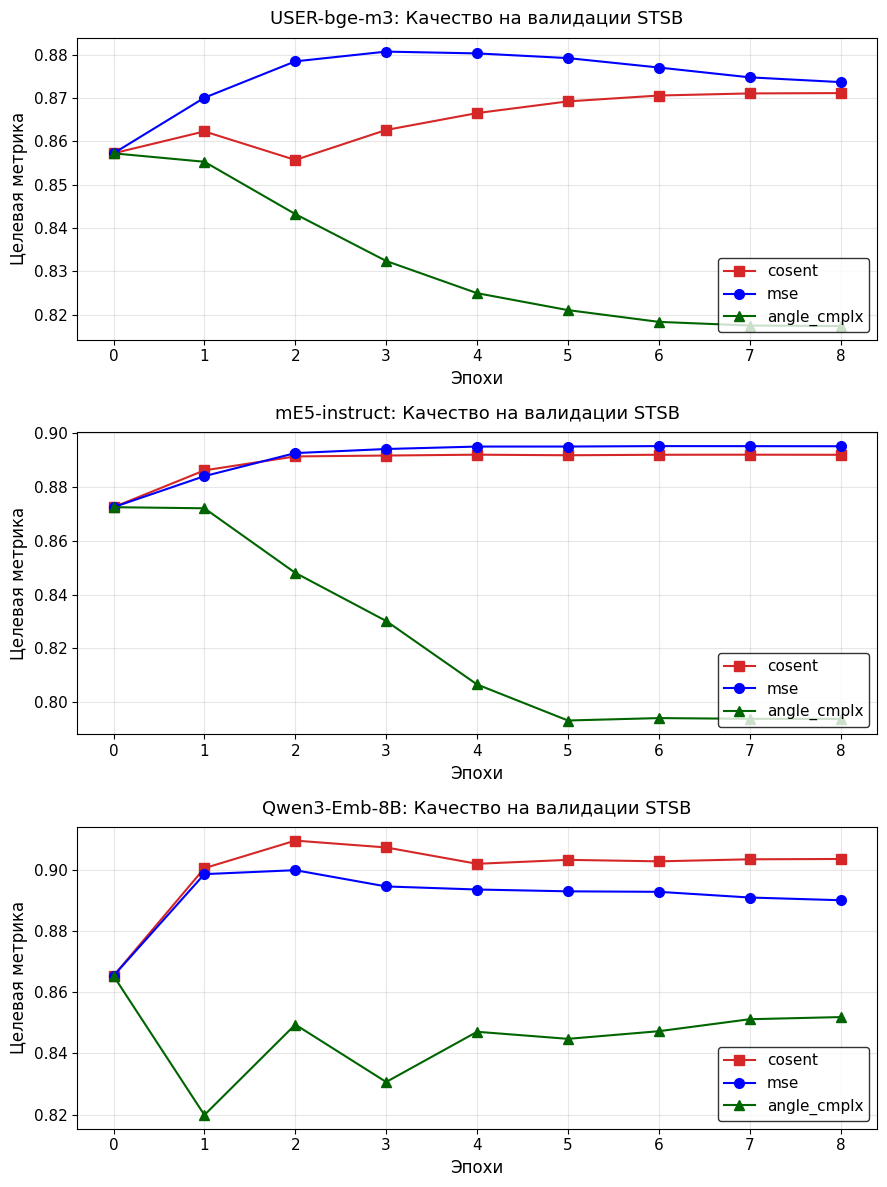

In [ ]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
    'legend.fontsize': 11
})

LOSS_COLORS = {
    'mse': 'blue',
    'cosent': 'tab:red',
    'angle_cmplx': 'darkgreen'
}

LOSS_MARKERS = {
    'mse': 'o',
    'cosent': 's',
    'angle_cmplx': '^'
}

def plot_combined_val_losses(results_dict, filename="losses.png"):
    models = list(results_dict.keys())
    fig, axes = plt.subplots(3, 1, figsize=(9, 12))

    for ax, model_name in zip(axes, models):
        histories = results_dict[model_name]
        for loss_type, hist in histories.items():
            if not hist: continue
            epochs = [r['epoch'] for r in hist]
            values = [r['val_stsb'] for r in hist]

            ax.plot(
                epochs, values,
                label=loss_type,
                color=LOSS_COLORS.get(loss_type, 'black'),
                marker=LOSS_MARKERS.get(loss_type, 'o'),
                linewidth=1.5,
                markersize=7
            )

        ax.set_title(f"{model_name}: Качество на валидации STSB", pad=10)
        ax.set_xlabel("Эпохи")
        ax.set_ylabel("Целевая метрика")
        ax.grid(True, linestyle='-', alpha=0.3)
        ax.legend(loc='lower right', frameon=True, facecolor='white', edgecolor='black')

    plt.tight_layout()
    plt.savefig(filename, dpi=300)
    print(f"Saved: {filename}")
    plt.show()

# Генерация общего графика для всех моделей
plot_combined_val_losses(RESULTS, "losses.png")

Saved: fig7_stsb_val_sts_train.png


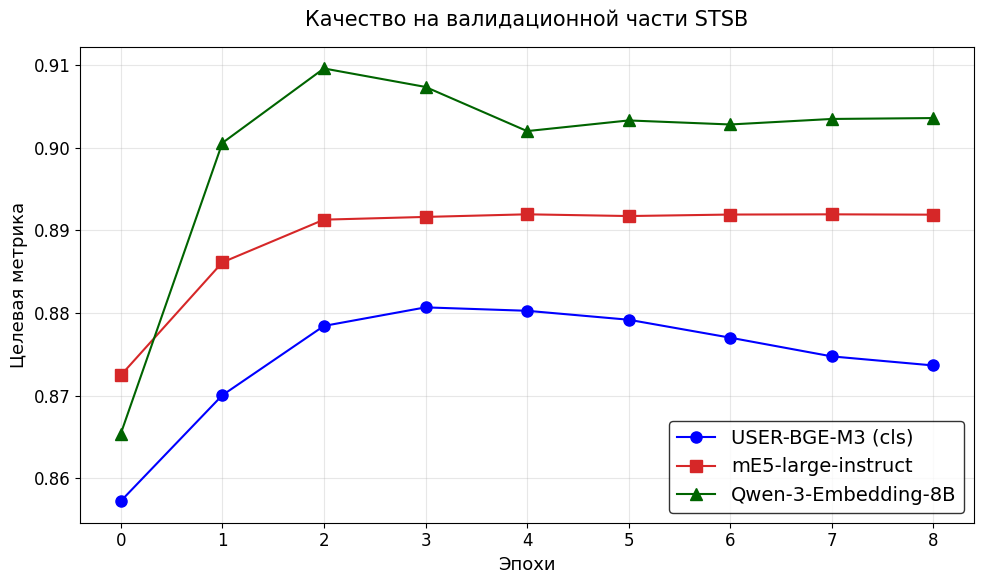

Saved: fig8_stsb_test_sts_train.png


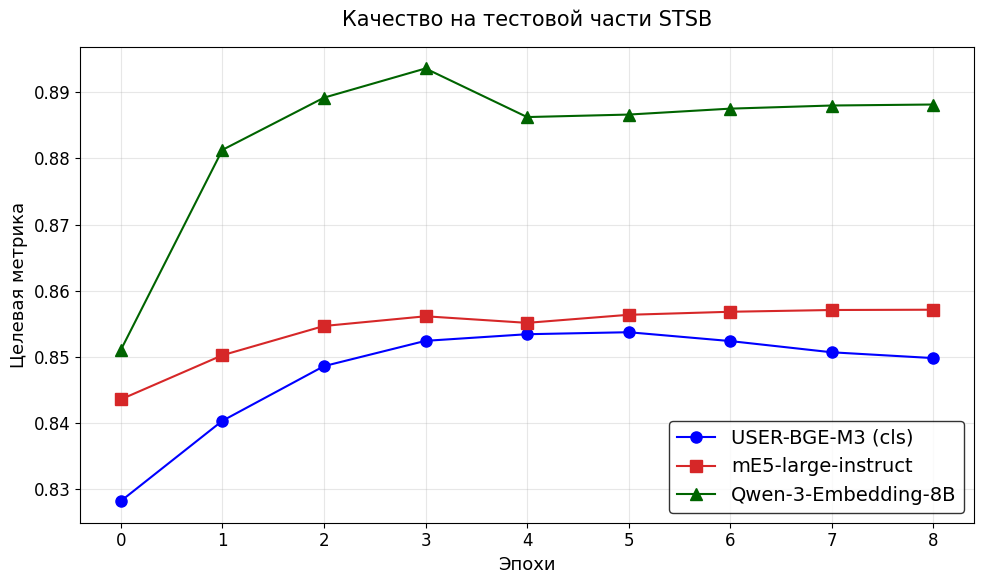

Saved: fig9_sts22_test_sts_train.png


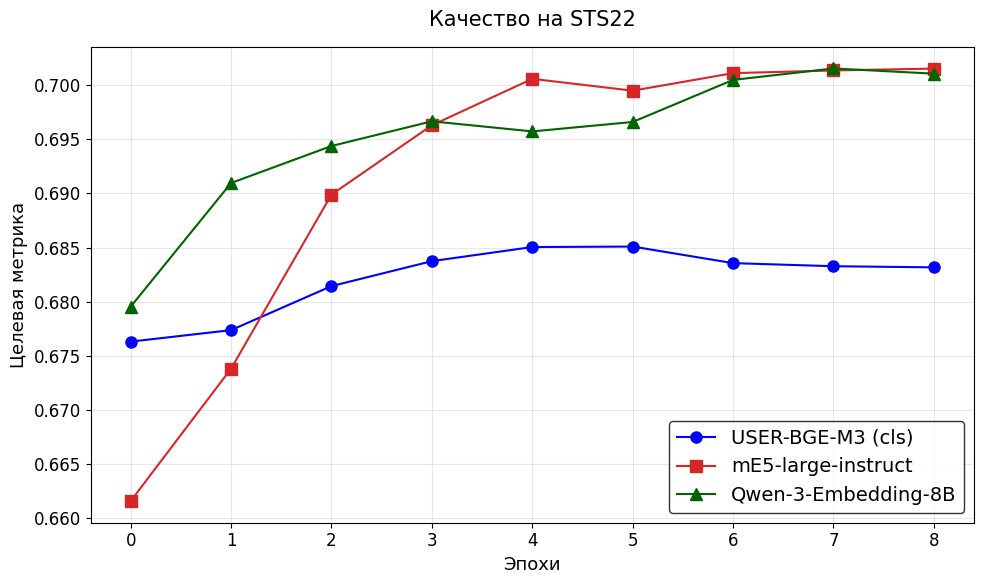

In [ ]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 15,
    'axes.labelsize': 13,
    'legend.fontsize': 14
})

# Custom colors and markers for the three best models
BEST_COLORS = {
    'USER-BGE-M3 (cls)': 'blue',
    'mE5-large-instruct': 'tab:red',
    'Qwen-3-Embedding-8B': 'darkgreen'
}

BEST_MARKERS = {
    'USER-BGE-M3 (cls)': 'o',
    'mE5-large-instruct': 's',
    'Qwen-3-Embedding-8B': '^'
}

def plot_sts_best_styled(results_dict, metric_key, title, filename, ylabel="Целевая метрика"):
    plt.figure(figsize=(10, 6))

    best_configs = [
        ('USER-bge-m3', 'mse', 'USER-BGE-M3 (cls)'),
        ('mE5-instruct', 'cosent', 'mE5-large-instruct'),
        ('Qwen3-Emb-8B', 'cosent', 'Qwen-3-Embedding-8B')
    ]

    for model_name, loss_name, display_label in best_configs:
        if model_name in results_dict and loss_name in results_dict[model_name]:
            history = results_dict[model_name][loss_name]
            if not history: continue

            epochs = [r['epoch'] for r in history]
            values = [r[metric_key] for r in history]

            plt.plot(
                epochs, values,
                label=display_label,
                color=BEST_COLORS.get(display_label, 'black'),
                marker=BEST_MARKERS.get(display_label, 'o'),
                linewidth=1.5,
                markersize=8
            )

    plt.title(title, pad=15)
    plt.xlabel("Эпохи")
    plt.ylabel(ylabel)
    plt.grid(True, linestyle='-', alpha=0.3)

    # Увеличенная и более чёткая легенда
    plt.legend(loc='lower right', frameon=True, facecolor='white', edgecolor='black')
    plt.tight_layout()

    # Сохранение файла
    plt.savefig(filename, dpi=300)
    print(f"Saved: {filename}")

    plt.show()

plot_sts_best_styled(RESULTS, "val_stsb", "Качество на валидационной части STSB", "fig7_stsb_val_sts_train.png")
plot_sts_best_styled(RESULTS, "test_stsb", "Качество на тестовой части STSB", "fig8_stsb_test_sts_train.png")
plot_sts_best_styled(RESULTS, "test_sts22", "Качество на STS22", "fig9_sts22_test_sts_train.png")

Saved: fig13_matryoshka.png


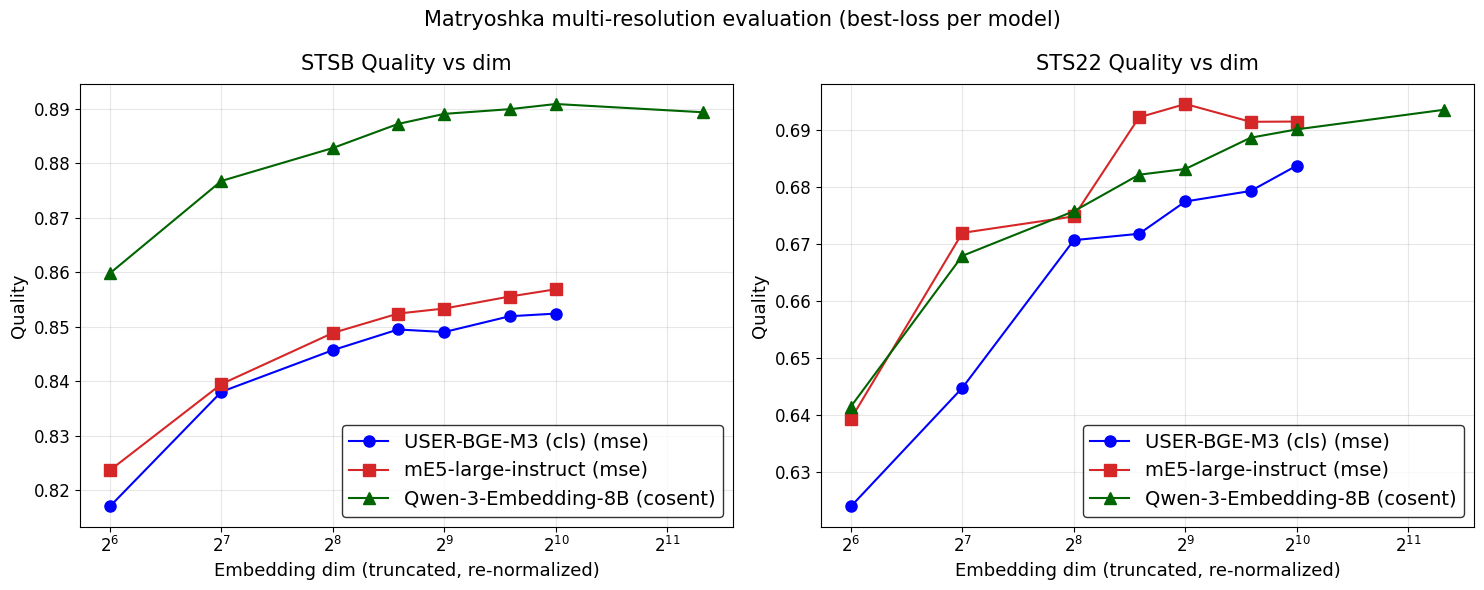

In [ ]:
# ----- Matryoshka: качество vs размерность для best-loss каждой модели -----
# Маппинг внутренних имен в красивые лейблы
MODEL_LABEL_MAP = {
    'USER-bge-m3': 'USER-BGE-M3 (cls)',
    'mE5-instruct': 'mE5-large-instruct',
    'Qwen3-Emb-8B': 'Qwen-3-Embedding-8B'
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
for model_name, by_loss in MATRYOSHKA_RES.items():
    if not by_loss: continue
    # выбираем лучший лосс по val_stsb на полной размерности
    best_loss = max(by_loss, key=lambda lt: max(by_loss[lt].values(), key=lambda r: r["val_stsb"])["val_stsb"])
    res = by_loss[best_loss]
    dims = sorted(res.keys())

    display_label = MODEL_LABEL_MAP.get(model_name, model_name)
    color = BEST_COLORS.get(display_label, 'black')
    marker = BEST_MARKERS.get(display_label, 'o')

    ax1.plot(
        dims, [res[d]["test_stsb"]  for d in dims],
        marker=marker, color=color, label=f"{display_label} ({best_loss})",
        linewidth=1.5, markersize=8
    )
    ax2.plot(
        dims, [res[d]["test_sts22"] for d in dims],
        marker=marker, color=color, label=f"{display_label} ({best_loss})",
        linewidth=1.5, markersize=8
    )

for ax, t in [(ax1, "STSB Quality vs dim"), (ax2, "STS22 Quality vs dim")]:
    ax.set_xlabel("Embedding dim (truncated, re-normalized)")
    ax.set_ylabel("Quality")
    ax.set_title(t, pad=10)
    ax.set_xscale("log", base=2)
    ax.grid(True, linestyle='-', alpha=0.3)
    ax.legend(loc='lower right', frameon=True, facecolor='white', edgecolor='black')

plt.suptitle("Matryoshka multi-resolution evaluation (best-loss per model)", fontsize=15)
plt.tight_layout()
plt.savefig("fig13_matryoshka.png", dpi=300)
print("Saved: fig13_matryoshka.png")
plt.show()

In [ ]:
# ----- Сводная таблица: для каждой пары (model, loss) — best-by-val эпоха -----
rows = []
for model_name in MODEL_SPECS:
    base = BASELINES.get(model_name, {})
    rows.append({
        "model": model_name, "loss": "baseline (frozen)",
        "best_epoch": 0,
        "val_stsb":   base.get("val_stsb",   float("nan")),
        "test_stsb":  base.get("test_stsb",  float("nan")),
        "test_sts22": base.get("test_sts22", float("nan")),
        "ckpt": "—",
    })
    for loss_type, hist in RESULTS[model_name].items():
        if not hist: continue
        # пропускаем эпоху 0 (это baseline в этом же hist)
        train_hist = [r for r in hist if r["epoch"] > 0]
        if not train_hist: continue
        best = max(train_hist, key=lambda r: r["val_stsb"])
        rows.append({
            "model": model_name, "loss": loss_type,
            "best_epoch": best["epoch"],
            "val_stsb":   best["val_stsb"],
            "test_stsb":  best["test_stsb"],
            "test_sts22": best["test_sts22"],
            "ckpt": CKPT_PATHS.get((model_name, loss_type), "—"),
        })

df = pd.DataFrame(rows)

# Δ к baseline по своей модели
def _delta(row, col):
    base = df[(df["model"] == row["model"]) & (df["loss"] == "baseline (frozen)")][col]
    if len(base) == 0 or pd.isna(base.iloc[0]): return float("nan")
    return row[col] - base.iloc[0]
for col in ["val_stsb", "test_stsb", "test_sts22"]:
    df[f"Δ_{col}"] = df.apply(lambda r: _delta(r, col), axis=1)

# среднее по двум тестам — удобно для ранжирования
df["test_mean"] = (df["test_stsb"] + df["test_sts22"]) / 2

df_sorted = df.sort_values(["model", "test_mean"], ascending=[True, False]).reset_index(drop=True)
print("=== Все эксперименты ===")
df_sorted


=== Все эксперименты ===


,model,loss,best_epoch,val_stsb,test_stsb,test_sts22,ckpt,Δ_val_stsb,Δ_test_stsb,Δ_test_sts22,test_mean
0,Qwen3-Emb-8B,cosent,2,0.909597,0.889169,0.694393,./checkpoints_stageC/Qwen3-Emb-8B__cosent.pt,0.044141,0.038015,0.014367,0.791781
1,Qwen3-Emb-8B,mse,2,0.899931,0.885761,0.686967,./checkpoints_stageC/Qwen3-Emb-8B__mse.pt,0.034474,0.034607,0.006941,0.786364
2,Qwen3-Emb-8B,baseline (frozen),0,0.865456,0.851154,0.680027,—,0.000000,0.000000,0.000000,0.765590
3,Qwen3-Emb-8B,angle_cmplx,8,0.851895,0.828977,0.658055,./checkpoints_stageC/Qwen3-Emb-8B__angle_cmplx.pt,-0.013562,-0.022177,-0.021972,0.743516
4,USER-bge-m3,mse,3,0.880673,0.852431,0.683742,./checkpoints_stageC/USER-bge-m3__mse.pt,0.023456,0.024208,0.007445,0.768086
5,USER-bge-m3,cosent,8,0.871107,0.841690,0.678666,./checkpoints_stageC/USER-bge-m3__cosent.pt,0.013890,0.013466,0.002370,0.760178
6,USER-bge-m3,baseline (frozen),0,0.857217,0.828224,0.676297,—,0.000000,0.000000,0.000000,0.752260
7,USER-bge-m3,angle_cmplx,1,0.855271,0.827877,0.674870,./checkpoints_stageC/USER-bge-m3__angle_cmplx.pt,-0.001946,-0.000347,-0.001426,0.751373
8,mE5-instruct,cosent,4,0.891940,0.855149,0.700606,./checkpoints_stageC/mE5-instruct__cosent.pt,0.019487,0.011573,0.039056,0.777877
9,mE5-instruct,mse,6,0.895125,0.856896,0.691467,./checkpoints_stageC/mE5-instruct__mse.pt,0.022672,0.013320,0.029918,0.774182


In [ ]:
# ----- Лучший лосс на каждой модели + лучшая модель в целом -----
print("=== Лучший лосс на каждой модели (по test_mean) ===")
best_per_model = []
for model_name in MODEL_SPECS:
    sub = df_sorted[(df_sorted["model"] == model_name) & (df_sorted["loss"] != "baseline (frozen)")]
    if len(sub) == 0: continue
    best = sub.iloc[0]   # уже отсортировано
    best_per_model.append({
        "model": model_name, "best_loss": best["loss"],
        "test_stsb": best["test_stsb"], "test_sts22": best["test_sts22"],
        "test_mean": best["test_mean"], "ckpt": best["ckpt"],
    })
df_best = pd.DataFrame(best_per_model).sort_values("test_mean", ascending=False).reset_index(drop=True)
print(df_best.to_string())

print("\n=== Чекпойнты для дальнейшего использования ===")
for r in best_per_model:
    print(f"  {r['model']:<18} best loss = {r['best_loss']:<12} ->  {r['ckpt']}")


=== Лучший лосс на каждой модели (по test_mean) ===
          model best_loss  test_stsb  test_sts22  test_mean                                          ckpt
0  Qwen3-Emb-8B    cosent   0.889169    0.694393   0.791781  ./checkpoints_stageC/Qwen3-Emb-8B__cosent.pt
1  mE5-instruct    cosent   0.855149    0.700606   0.777877  ./checkpoints_stageC/mE5-instruct__cosent.pt
2   USER-bge-m3       mse   0.852431    0.683742   0.768086      ./checkpoints_stageC/USER-bge-m3__mse.pt

=== Чекпойнты для дальнейшего использования ===
  USER-bge-m3        best loss = mse          ->  ./checkpoints_stageC/USER-bge-m3__mse.pt
  mE5-instruct       best loss = cosent       ->  ./checkpoints_stageC/mE5-instruct__cosent.pt
  Qwen3-Emb-8B       best loss = cosent       ->  ./checkpoints_stageC/Qwen3-Emb-8B__cosent.pt
